# Redes Neurais Artificiais

## Autores

| Nome | nUSP |
| :--- | :--- |
| Débora da Silva Morais | 15615790 |
| Guilherme e Abreu Barreto | 12543033 |

## Introdução

O presente notebook trata-se da aplicação de uma técnica de rede neural artificial, o [percepton multicamadas](https://pt.wikipedia.org/wiki/Perceptron_multicamadas) (_Multilayer Perceptron_, MLP) para a tarefa de classificação vista nos exercícios anteriores. A seguir, explicitamos as etapas para execução desta análise.

## Carregamento de dependências

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    r2_score,
    mean_squared_error as MSE,
    auc,
)

## Constantes

A seguir são definidos os seguintes atributos:

- `SEED`: valor inteiro utilizado para cálculo de números pseudo-aleatórios. Assegura a reprodutibilidade do notebook em procedimentos probabilísticos como a geração pseudo-aleatória de divisões de treino e validação.

- `WDTS_DATASETS`: Referem-se aos arquivos onde encontram-se os dados de referência para o experimento de classificação.

- `NSQD_DATASET`: Refere-se ao arquivo onde se localiza os dados de referência para o experimento de regressão.

In [2]:
SEED = 42

# Dados referentes a tarefa de classificação
WDTS_DATASETS_FOLDER = '../generated-datasets-for-burst-detection-in-water-distribution-systems'
WDTS_DATASETS = [
    f'{WDTS_DATASETS_FOLDER}/WDts{i}/WDts{i}_dataset.csv' for i in range(1, 5)
]

# Dados referentes a tarefa de regressão
NSQD_DATASET = '../NSQD_v4.02_2015.csv'

## Uso de MLP para classificação

### Carregamento dos dados

In [3]:
def load_wdts_data(
    csv_path: str, features: list[str], target: str
) -> tuple[pd.DataFrame, pd.Series]:
    df = pd.read_csv(
        csv_path,
        dtype={target: bool},
        index_col=False,
        sep=';',
    )
    df = df[df[target].notna()]
    df.info()
    return df[features].fillna(df[features].mean()), df[target]

In [ ]:
### Teste e escolha dos hiperparâmetros ótimos

In [14]:
def tune_hyper_parameters(
    X_train: pd.DataFrame, y_train: pd.Series
) -> GridSearchCV:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            early_stopping=True, # Interromper ajuste ao encontrar uma queda substancial nos ganhos de desempenho
            validation_fraction=0.1, # Conjunto de validação para testar o ganho de desempenho
            n_iter_no_change=10, # Tolerância máxima para iterações sem alterações em ganho de desempenho
            max_iter=1000, # Numero máximo de iterações de treino
            random_state=SEED
        ))
    ])
    
    param_grid = {
        # Diferentes tamanhos e quantidades de camadas de neurônios: cada elemento de cada tupla descreve a uma camada e a quantidade de neurônios nesta.
        'mlp__hidden_layer_sizes': [
            (50,),
            (100,),
            (50, 25),
            (100, 50),
            (30, 30, 30)
        ],
        # Diferentes funções de ativação
        'mlp__activation': [
            'relu', # Rectified Linear Unit
            'tanh'  # Hyperbolic Tangent
        ],
        'mlp__alpha': [0.0001, 0.001, 0.01], # Regularização
        'mlp__learning_rate_init': [0.001, 0.01], # Taxa de aprendizado
        'mlp__batch_size': [32, 64, 'auto'], # Tamanho de cada lote
    }
    
    gs = GridSearchCV(
        pipeline,
        param_grid,
        scoring='f1',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    return gs.fit(X_train, y_train)

In [ ]:
### Avaliação dos resultados obtidos

In [19]:
def evaluate_results(
    X_test: pd.DataFrame,
    y_test: pd.Series,
    gs: GridSearchCV,
    testset_name: str,
) -> None:
    classifier = gs.best_estimator_
    y_pred = classifier.predict(X_test)

    # Imprimir matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(8,6))
    labels = ["Falso", "Verdadeiro"]
    sns.heatmap(
        cm_percentage,
        annot=True,
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        fmt='.2f'
    )
    plt.xlabel('Previsão')
    plt.ylabel('Realidade')
    plt.title(f"Matriz de confusão, conjunto de teste {testset_name}")
    plt.show()

    # Imprimir Curva ROC
    y_pred_proba = classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, theresholds = roc_curve(y_test, y_pred_proba)

    plt.figure(figsize=(10,8))
    plt.plot(
        fpr,
        tpr,
        color='darkorange',
        lw=2,
        label=f'Área sob a curva = {auc(fpr, tpr):.4f}'
    )
    plt.plot(
        [0, 1],
        [0, 1],
        color='navy',
        lw=2,
        linestyle='--',
        label='Classificador aleatório'
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de falsos positivos')
    plt.ylabel('Taxa de verdadeiros positivos')
    plt.title(f'Curva ROC, conjunto de teste {testset_name}')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Sumário final do modelo
    print("\n" + "=" * 60)
    print("SUMÀRIO DOS MELHORES HIPER-PARÂMETROS")
    print("="*60)
    print('Distribuição de neurônios por camada:')
    for layer, neurons in enumerate(
        gs.best_params_['mlp__hidden_layer_sizes'], start=1
    ):
        print(f'- Camada {layer}: {neurons} neurônios')
    if gs.best_params_['mlp__activation'] == 'relu':
        print(f'Método de ativação: ReLU (Rectified Linear Unit)')
    else:
        print(f'Método de ativação: TanH (Hyperbolic Tangent)')
    print(f'Alpha: {gs.best_params_['mlp__alpha']}')
    print(f'Taxa de aprendizado inicial: {gs.best_params_['mlp__learning_rate_init']}')
    print(f'Tamanho do lote: {gs.best_params_['mlp__batch_size']}')

In [ ]:
### Consolidação do processo em uma função replicável

In [20]:
def ANN_classification_pipeline(csv_path: str) -> None:
    target = 'burst'
    features = [
        f'flow_meter{i}' for i in range(1, 5)
    ] + [
        f'{i}_press' for i in [3, 12, 36, 50, 60, 84, 93, 112, 138, 139]
    ]
    X, y = load_wdts_data(csv_path, features, target)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    evaluate_results(
        X_test,
        y_test,
        tune_hyper_parameters(X_train, y_train),
        csv_path.rsplit('/', 1)[-1],
    )

In [ ]:
### Aplicação do processo para os diferentes Datasets

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Fitting 5 folds for each of 180 candidates, totalling 900 fits


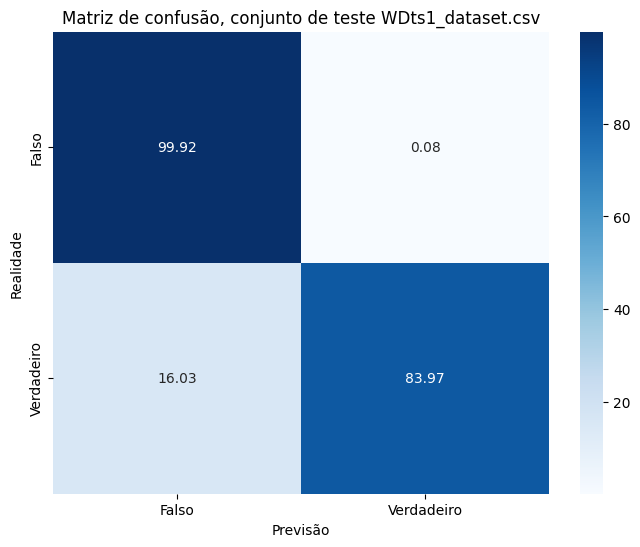

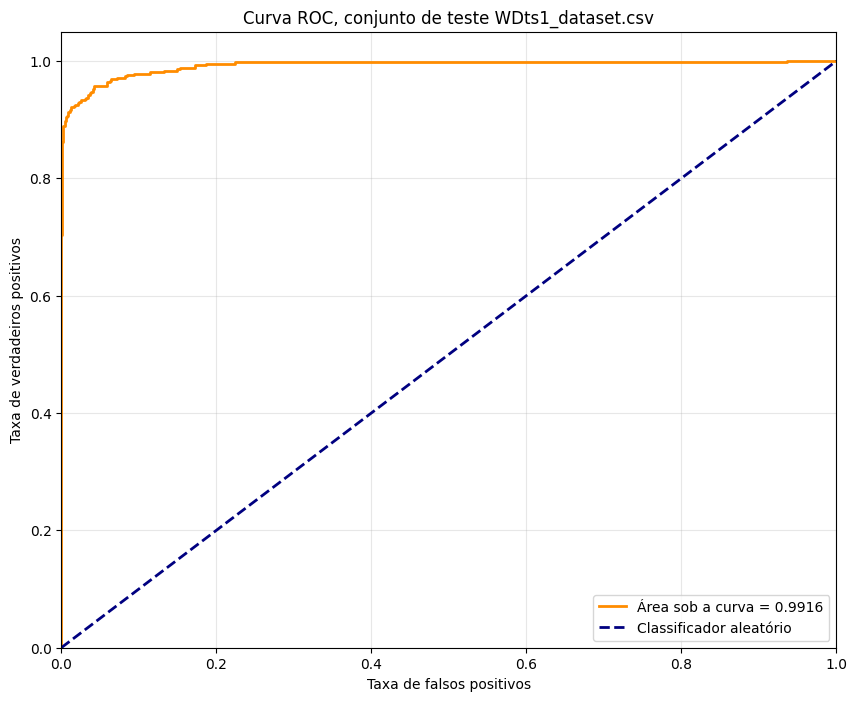


SUMÀRIO DOS MELHORES HIPER-PARÂMETROS
Distribuição de neurônios por camada:
- Camada 1: 30 neurônios
- Camada 2: 30 neurônios
- Camada 3: 30 neurônios
Método de ativação: ReLU (Rectified Linear Unit)
Alpha: 0.01
Taxa de aprendizado inicial: 0.001
Tamanho do lote: 64


In [21]:
ANN_classification_pipeline(WDTS_DATASETS[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Fitting 5 folds for each of 180 candidates, totalling 900 fits


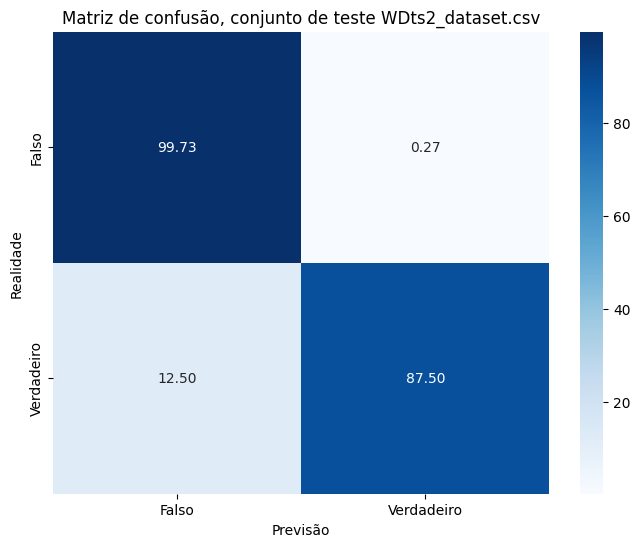

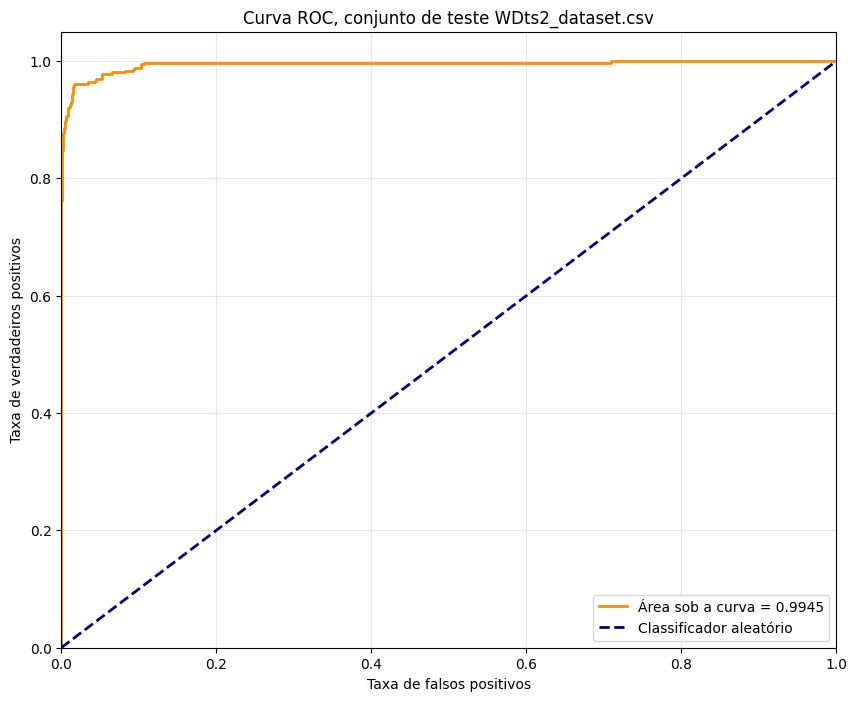


SUMÀRIO DOS MELHORES HIPER-PARÂMETROS
Distribuição de neurônios por camada:
- Camada 1: 50 neurônios
- Camada 2: 25 neurônios
Método de ativação: ReLU (Rectified Linear Unit)
Alpha: 0.001
Taxa de aprendizado inicial: 0.001
Tamanho do lote: 64


In [22]:
ANN_classification_pipeline(WDTS_DATASETS[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Fitting 5 folds for each of 180 candidates, totalling 900 fits


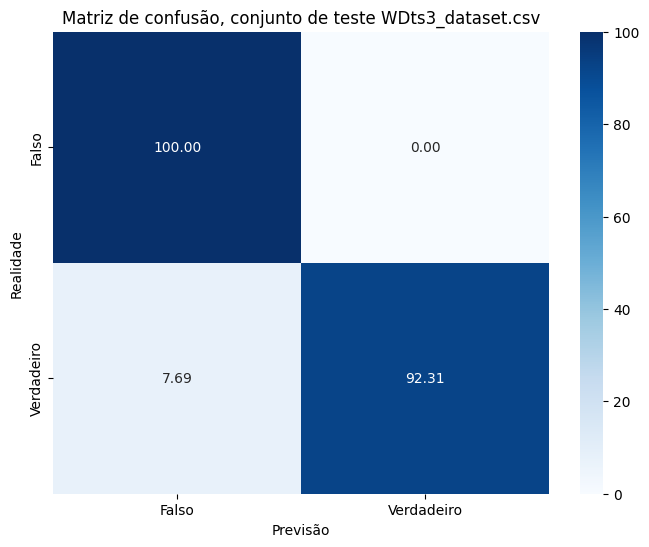

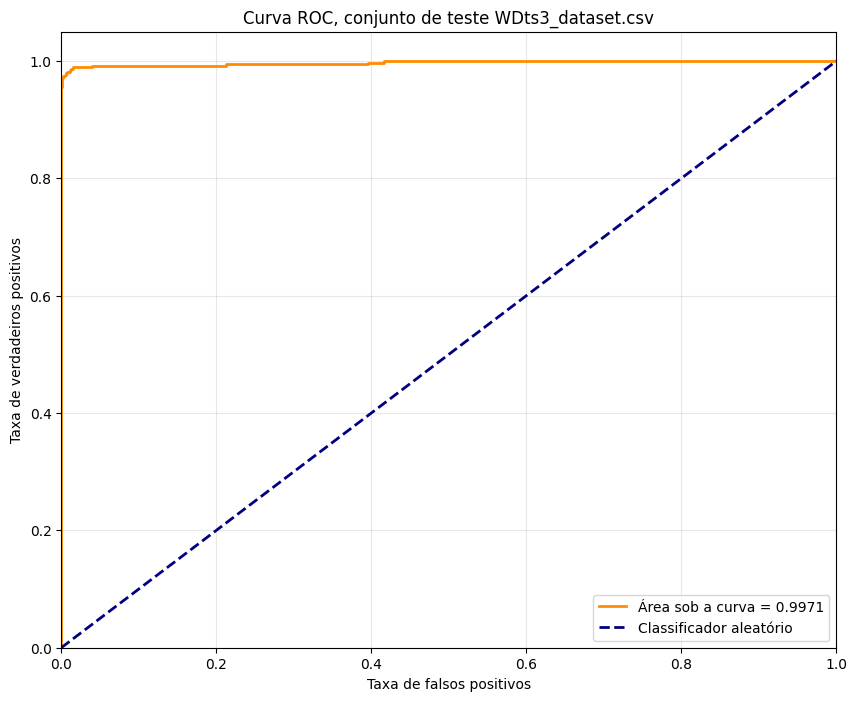


SUMÀRIO DOS MELHORES HIPER-PARÂMETROS
Distribuição de neurônios por camada:
- Camada 1: 30 neurônios
- Camada 2: 30 neurônios
- Camada 3: 30 neurônios
Método de ativação: TanH (Hyperbolic Tangent)
Alpha: 0.001
Taxa de aprendizado inicial: 0.001
Tamanho do lote: 32


In [23]:
ANN_classification_pipeline(WDTS_DATASETS[2])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        35040 non-null  object 
 1   burst        35040 non-null  bool   
 2   flow_meter1  35040 non-null  float64
 3   flow_meter2  35040 non-null  float64
 4   flow_meter3  35040 non-null  float64
 5   flow_meter4  35040 non-null  float64
 6   3_press      35040 non-null  float64
 7   12_press     35040 non-null  float64
 8   36_press     35040 non-null  float64
 9   50_press     35040 non-null  float64
 10  60_press     35040 non-null  float64
 11  84_press     35040 non-null  float64
 12  93_press     35040 non-null  float64
 13  112_press    35040 non-null  float64
 14  138_press    35040 non-null  float64
 15  139_press    35040 non-null  float64
dtypes: bool(1), float64(14), object(1)
memory usage: 4.0+ MB
Fitting 5 folds for each of 180 candidates, totalling 900 fits


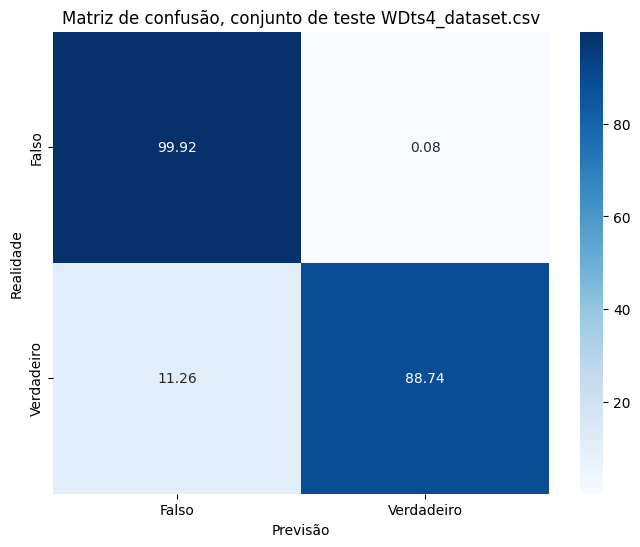

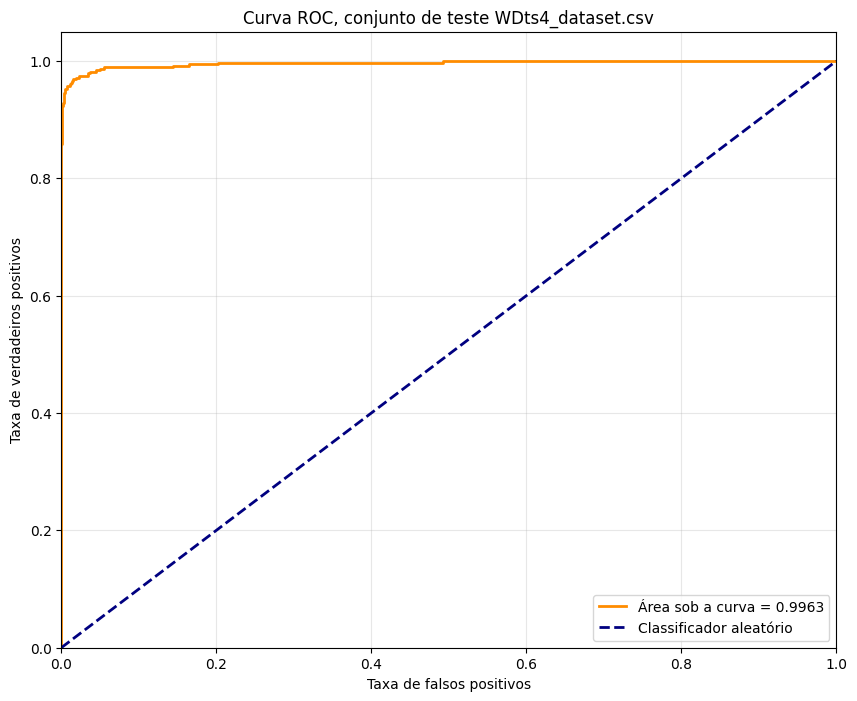


SUMÀRIO DOS MELHORES HIPER-PARÂMETROS
Distribuição de neurônios por camada:
- Camada 1: 30 neurônios
- Camada 2: 30 neurônios
- Camada 3: 30 neurônios
Método de ativação: ReLU (Rectified Linear Unit)
Alpha: 0.001
Taxa de aprendizado inicial: 0.001
Tamanho do lote: 32


In [24]:
ANN_classification_pipeline(WDTS_DATASETS[3])